In [2]:
import numpy as np
from math import sqrt
from pprint import pprint

# Datasets de ejemplo y modelos de regresión lineal
from sklearn import datasets, linear_model, metrics

# Modelo base (baseline) que predice siempre la media
from sklearn.dummy import DummyRegressor

# Herramientas de validación y partición de datos
from sklearn.model_selection import (
    cross_validate,       # validación cruzada con múltiples métricas
    KFold,                # partición en K subconjuntos
    cross_val_predict,    # obtener predicciones por validación cruzada
    train_test_split,     # dividir en train y test
    cross_val_score       # validación cruzada con una sola métrica
)

# Preprocesamiento (normalización, estandarización...)
from sklearn import preprocessing

# Métrica de error cuadrático medio y utilidad para crear scorers personalizados
from sklearn.metrics import make_scorer, mean_squared_error

import matplotlib.pyplot as plt

In [7]:
# Carga de datos.
#datos = datasets.load_boston()
datos = datasets.fetch_california_housing()
# print(datos)
X = datos.data
y = datos.target
print('Dimensiones de X: ', np.shape(X))
print(y)

Dimensiones de X:  (20640, 8)
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [9]:
# Métricas de evaluación.
metricas = {
  'MAE':  'neg_mean_absolute_error',
  'RMSE': make_scorer(lambda y, y_pred:
                      sqrt(metrics.mean_squared_error(y, y_pred)),
                      greater_is_better=False),
  'MAPE': make_scorer(lambda y, y_pred:
                      np.mean(np.abs((y - y_pred) / y)) * 100,
                      greater_is_better=False),
  'R2':   'r2',}

In [11]:
# 1) PARTICIÓN HOLD-OUT (división simple train/test)

# Divide el dataset en dos subconjuntos:
#   X_training, y_training → 80% de los datos, para entrenar el modelo
#   X_testing,  y_testing  → 20% de los datos, para evaluar el modelo
# random_state=42 → fija la semilla aleatoria para que la partición sea reproducible
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)

print(np.shape(X_training))  # → debería ser (16512, 8) aprox. (80% de ~20640 muestras)

(16512, 8)


In [12]:
# 2) EXTRACCIÓN DE CARACTERÍSTICAS
# 3) SELECCIÓN DE ATRIBUTOS (técnicas del tema 2)

# 4) ESTANDARIZACIÓN DE LOS DATOS DE ENTRENAMIENTO
# StandardScaler transforma cada feature para que tenga media=0 y desviación estándar=1
standardizer = preprocessing.StandardScaler()

# fit() calcula la media y desviación estándar de X_training (SOLO del training)
stdr_trained = standardizer.fit(X_training)

# transform() aplica la estandarización: X_estand = (X - media) / std
X_stdr = stdr_trained.transform(X_training)

In [13]:
# 5) Construcción del algoritmo de aprendizaje.
reg = linear_model.LinearRegression(fit_intercept=True)

In [14]:
# 5.1) Validación cruzada interna

# Extraer directamente resultados del error para cada bolsa, en lugar de las predicciones
cross_val_results = cross_validate(reg, X_stdr, y_training,
                                    cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
#print("cross_val_MAE:   %0.4f +/- %0.4f" % (-cross_val_results.mean(), cross_val_results.std()))
pprint(cross_val_results)

{'fit_time': array([0.02785563, 0.00511336, 0.00477862, 0.00466084, 0.00463223]),
 'score_time': array([0.00335956, 0.00263405, 0.00250936, 0.0025506 , 0.00243902]),
 'test_MAE': array([-0.54071407, -0.52878981, -0.51274193, -0.53512422, -0.52793364]),
 'test_MAPE': array([-31.74769388, -31.65516613, -30.97054077, -32.61432353,
       -30.685065  ]),
 'test_R2': array([0.60970239, 0.60411343, 0.6354319 , 0.60076148, 0.60727452]),
 'test_RMSE': array([-0.73389779, -0.72516701, -0.69726867, -0.73337185, -0.71284225])}


In [16]:
reg = linear_model.LinearRegression(fit_intercept=True)
# 5.2) Entrenamiento con todos los datos para obtener los coeficientes del modelo.
model = reg.fit(X_stdr, y_training)

# Obtención de los coeficientes del modelo.
w = model.coef_
print('Model coeficients: \n', w)

# Obtención del término independiente del modelo.
w_0 = model.intercept_
print('\nTérmino independiente: ', w_0)

Model coeficients: 
 [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]

Término independiente:  2.071946937378619


In [ ]:
# ---- PREDICCIÓN ---- #

In [17]:
# 6) Extracción de las características de test
# 7) Selección de los atributos de test
# 8) Estandarización de las característiacs de test
X_test_stdr = stdr_trained.transform(X_testing)

In [18]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)

In [22]:
# Cálculo de las métricas de evaluación.
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = metrics.root_mean_squared_error(y_testing, y_pred_test)
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)
R2 = metrics.r2_score(y_testing, y_pred_test)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2:   %.4f' % R2)

MAE:  0.5332
MSE: 0.5559
RMSE: 0.7456
MAPE: 0.3195
R2:   0.5758


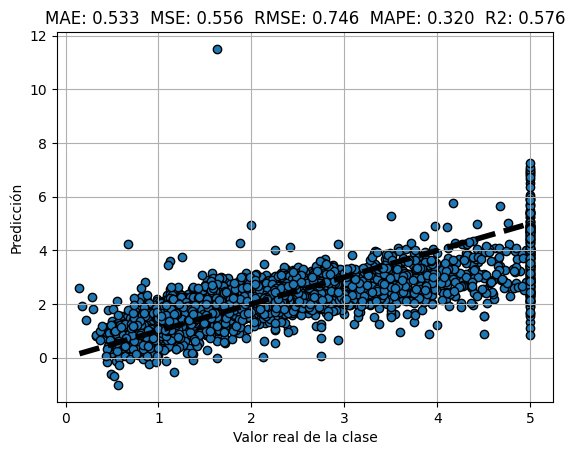

In [23]:
# Gráfica de realidad vs. predicción.
fig, ax = plt.subplots()
ax.scatter(y_testing, y_pred_test, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f  MSE: %.3f  RMSE: %.3f  MAPE: %.3f  R2: %.3f" %
          (MAE,MSE,RMSE,MAPE,R2))
plt.grid()
plt.show()

¿Que puede estar pasando?    
Ha valores altos se esta saturando, como nuetro valor real maximo era 5, en real al tener valores mayores que 5 estos se han colapsado en el 5.    
Luego tambien hay un outlier en el valor 12 del eje y